# Geo-Lift Incrementality Test - walkthrough

**The question:** when a brand spends on ads, did the ads *cause* the extra sales, or
would those customers have bought anyway? The goal of this method and test is to help us understand the counterfactual, rather than conversions.

A **geo-lift** answers it by running an experiment across geographies: change spend in
a set of *treatment* regions, leave others alone, and compare. The trick is building a
good stand-in for "what the treatment regions would have done without the campaign." We
build that stand-in with a **synthetic control**: a weighted blend of untreated regions
that tracked the treatment regions closely *before* the campaign.

This notebook runs the whole thing on Meta's open GeoLift example data. To check that
the method actually works, we inject a **known +10% lift** into the treatment group and
see whether we recover it.

In [66]:
import json
import numpy as np
import pandas as pd
import pyreadr
from scipy.optimize import nnls
from scipy.stats import norm
from sklearn.linear_model import BayesianRidge
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

RNG = np.random.default_rng(42)   # reproducible

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# treatment / counterfactual / donor / good-news colors
C_TREAT, C_CF, C_DONOR, C_OK = "#1f4e8c", "#c23b4e", "#9aa5b1", "#2e7d4f"

OUT = {}   # collects every headline number for results.json

## 1. Load the data

Meta's GeoLift package ships example data as R `.rda` files. `pyreadr` reads them into
pandas. Each row is one city on one day, with `Y` = daily conversions.

In [69]:
df = pyreadr.read_r("data/GeoLift_PreTest.rda")["GeoLift_PreTest"]
df["date"] = pd.to_datetime(df["date"])

# reshape to a grid: rows = days, columns = cities, values = daily conversions
wide = df.pivot(index="date", columns="location", values="Y").sort_index()

print(wide.shape[1], "cities,", wide.shape[0], "days,",
      wide.index.min().date(), "to", wide.index.max().date())
wide.iloc[:4, :5]

40 cities, 90 days, 2021-01-01 to 2021-03-31


location,atlanta,austin,baltimore,baton rouge,boston
date,,,,,
2021-01-01,3384,2124,3856,2617,3122
2021-01-02,3904,2258,3821,2609,3266
2021-01-03,5734,2994,5348,3132,4393
2021-01-04,4311,2964,3915,2554,5050


## 2. Design the test: pre-period vs test window

Everything hinges on the **pre-period**, the stretch before the "campaign" where we
learn how the treatment regions normally behave relative to the controls. We fit the
synthetic control on the pre-period, then watch the **test window** for a gap.

Here we hold out the last 10 days as the test window and use the first 80 to fit.

In [72]:
T = len(wide)
TEST_LEN = 10

pre_idx = np.arange(0, T - TEST_LEN)        # days used to fit the counterfactual
test_idx = np.arange(T - TEST_LEN, T)       # days we measure the lift over

print("pre-period:", len(pre_idx), "days   test window:", TEST_LEN, "days")

pre-period: 80 days   test window: 10 days


## 3. Pick the treatment group and the donor pool

The *treatment group* is the regions that would get the spend change. The *donor pool*
is every other region, and the synthetic control is built only from donors.

To avoid cherry-picking, I take five mid-volume cities (not the biggest or smallest).
I aggregate them into one treated series, because a geo-lift measures the group's
combined lift, not each city separately.

In [75]:
means = wide.iloc[pre_idx].mean().sort_values()
middle = len(means) // 2
treatment = list(means.iloc[middle - 2 : middle + 3].index)   # 5 mid-volume cities

donors_all = [c for c in wide.columns if c not in treatment]
treat_series = wide[treatment].sum(axis=1).values.astype(float)

print("treatment group:", treatment)
print("donor pool size:", len(donors_all))

treatment group: ['cleveland', 'denver', 'san diego', 'san antonio', 'new york']
donor pool size: 35


## 4. Market matching: choose the control markets

Not every donor is useful. We want donors whose pre-period movement looks like the
treatment group's, so the blend of them is a believable counterfactual. I rank donors
by their pre-period correlation with the treated series and keep the top 20.

This is the "control selection" step. A bad match here invalidates everything
downstream so qualifying the markets is necessary before any modeling.

In [85]:
t_pre = treat_series[pre_idx]
corr = {c: np.corrcoef(t_pre, wide[c].values[pre_idx])[0, 1] for c in donors_all}

matched = [c for c, _ in sorted(corr.items(), key=lambda kv: -kv[1])[:20]]

Dpre = wide[matched].values[pre_idx].astype(float)   # donor matrix, pre-period
Dall = wide[matched].values.astype(float)            # donor matrix, full timeline

#print(corr)
#print(matched)

print("kept", len(matched), "matched donors")

kept 20 matched donors


## 5. Build the synthetic control

The synthetic control is a weighted sum of the matched donors. We find weights `w`
that make the donor blend track the treated series as closely as possible **over the
pre-period**, then carry those same weights forward into the test window to get the
counterfactual.

I use **non-negative least squares** (weights >= 0). Non-negativity keeps the
counterfactual interpretable (you can't "short" a region) and acts as light
regularization. The weights don't have to sum to 1, allowing the blend scale up to
match an aggregate of several cities.

In [100]:
def fit_sc(target_pre, donors_pre):
    # non-negative least squares: min || donors_pre @ w - target_pre ||, with w >= 0
    weights, _ = nnls(donors_pre, target_pre)
    return weights

w = fit_sc(treat_series[pre_idx], Dpre)
cf = Dall @ w
#print(w)

pre_mape = np.mean(np.abs(treat_series[pre_idx] - cf[pre_idx]) / treat_series[pre_idx])
OUT["pre_fit_mape_pct"] = round(pre_mape * 100, 2)
print(f"pre-period fit error (MAPE): {pre_mape*100:.2f}%   <- low is good")

pre-period fit error (MAPE): 2.89%   <- low is good


### Check pre-period parity

Before trusting any lift, the counterfactual has to match the treated series *before*
the test window. If they already diverge in the pre-period, the method can't tell a
real lift from a pre-existing gap. A tight overlap here is what earns the right to
read the post-period gap as causal.

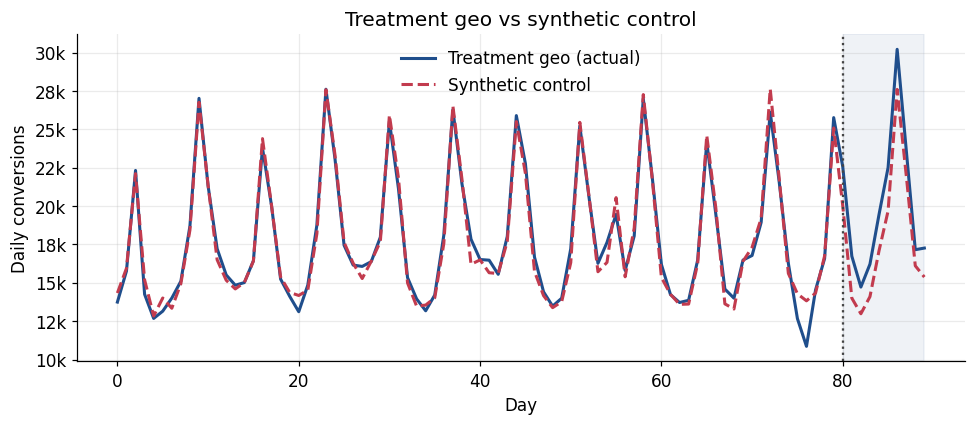

In [103]:
# inject a known +10% lift into the treatment group's test window only
TRUE_LIFT = 0.10
treat_obs = treat_series.copy()
treat_obs[test_idx] = treat_series[test_idx] * (1 + TRUE_LIFT)

# the pre-period is untouched, so refitting gives the same weights
w_obs = fit_sc(treat_obs[pre_idx], Dpre)
cf_obs = Dall @ w_obs

import os
os.makedirs("figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(treat_obs, color=C_TREAT, lw=2, label="Treatment geo (actual)")
ax.plot(cf_obs, color=C_CF, lw=2, ls="--", label="Synthetic control")
ax.axvspan(test_idx[0], T - 1, color=C_TREAT, alpha=0.07)
ax.axvline(test_idx[0], color="#444", ls=":")
ax.set_title("Treatment geo vs synthetic control")
ax.set_xlabel("Day")
ax.set_ylabel("Daily conversions")
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

fig.tight_layout()
fig.savefig("figures/01_parity.png", bbox_inches="tight")
plt.show()

## 6. Estimate the lift

The lift is the gap between what actually happened in the treatment regions and what
the synthetic control says would have happened, summed over the test window.

We injected +10%, so a good estimate lands near there. It won't be exactly 10% as the treated regions also have their own test-window noise. The confidence interval,
computed next, is what tells us how much to trust the point estimate.

In [106]:
act = treat_obs[test_idx]      # actual conversions in the test window
cft = cf_obs[test_idx]         # counterfactual conversions in the test window

pct_lift = (act.sum() - cft.sum()) / cft.sum()
OUT["sc_pct_lift"] = round(pct_lift * 100, 2)
print(f"estimated incremental lift: {pct_lift*100:.2f}%   (true injected: {TRUE_LIFT*100:.0f}%)")

estimated incremental lift: 12.03%   (true injected: 10%)


## 7. Is it real? The placebo (permutation) test

A number alone isn't evidence. To know whether a ~12% gap is more than noise, we ask:
how big a "lift" would we estimate for groups that got **no** treatment?

We draw many random same-size groups from the donor pool, build a synthetic control for
each, and record its test-window effect. That's the distribution of effects from noise
alone. If the real lift sits far out in the tail, it's unlikely to be chance. The share
of placebo effects as large as the real one is the permutation p-value.

In [109]:
N_PLACEBO = 200
placebo = []

for _ in range(N_PLACEBO):
    group = list(RNG.choice(donors_all, size=len(treatment), replace=False))
    rest = [d for d in donors_all if d not in group]

    pseudo_treat = wide[group].sum(axis=1).values.astype(float)
    wk = fit_sc(pseudo_treat[pre_idx], wide[rest].values[pre_idx].astype(float))
    cfk = wide[rest].values.astype(float) @ wk

    if cfk[test_idx].sum() > 0:
        effect = (pseudo_treat[test_idx].sum() - cfk[test_idx].sum()) / cfk[test_idx].sum()
        placebo.append(effect)

placebo = np.array(placebo)
null_sd = placebo.std()
p_val = np.mean(np.abs(placebo) >= abs(pct_lift))
ci = (pct_lift - 1.96 * null_sd, pct_lift + 1.96 * null_sd)

OUT.update(
    placebo_null_sd_pct=round(null_sd * 100, 2),
    perm_p_value=round(float(p_val), 4),
    sc_ci_lo_pct=round(ci[0] * 100, 2),
    sc_ci_hi_pct=round(ci[1] * 100, 2),
    n_placebo=len(placebo),
)
print(f"placebo null sd:     {null_sd*100:.2f}%")
print(f"permutation p-value: {p_val:.4f}")
print(f"95% CI for the lift: [{ci[0]*100:.1f}%, {ci[1]*100:.1f}%]")

placebo null sd:     3.03%
permutation p-value: 0.0000
95% CI for the lift: [6.1%, 18.0%]


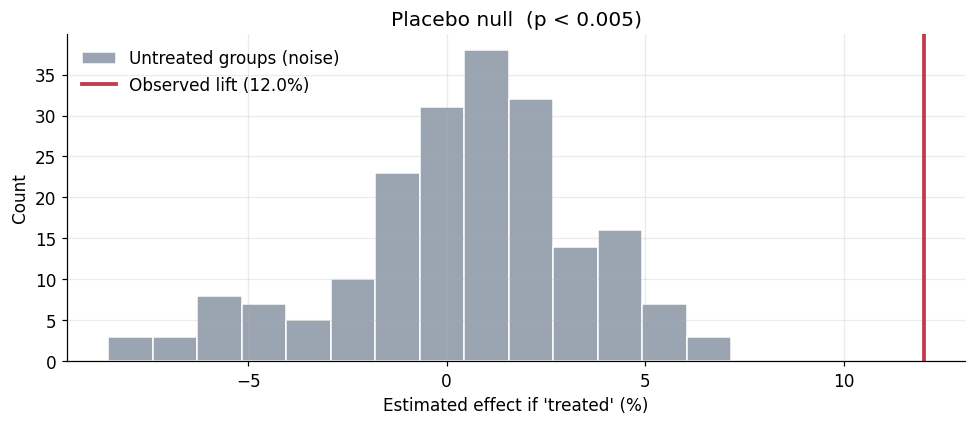

In [111]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(placebo * 100, bins=14, color=C_DONOR, edgecolor="white", label="Untreated groups (noise)")
ax.axvline(pct_lift * 100, color=C_CF, lw=2.5, label=f"Observed lift ({pct_lift*100:.1f}%)")

pstr = f"p < {1/len(placebo):.3f}" if p_val == 0 else f"p = {p_val:.3f}"
ax.set_title(f"Placebo null  ({pstr})")
ax.set_xlabel("Estimated effect if 'treated' (%)")
ax.set_ylabel("Count")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("figures/04_placebo.png", bbox_inches="tight")
plt.show()

## 7b. Stress-testing the counterfactual

The lift estimate is only as good as the counterfactual behind it, and a synthetic
control can cheat: with enough donors it can fit the pre-period almost perfectly and
still be a bad predictor of what comes next. 

To guard against that, I employ two checks:
The first asks whether the weights generalize to data they were not fitted on and the second asks
whether the method stays quiet when there is nothing to find.

### Backtest: do the weights generalize, or just overfit?

The weights are chosen to minimize pre-period error, so a good in-sample fit is
guaranteed and proves nothing on its own. The real question is out-of-sample. A single
held-out window is a coin flip (it might land on an odd week), so I use expanding-window
cross-validation: fit on the past, predict the next stretch the weights never saw, step
forward, repeat. If the averaged out-of-sample error stays close to the in-sample error,
the donor relationship is stable rather than memorized.

in-sample fit:               2.89% MAPE
out-of-sample (5 folds):     2.93% MAPE  (range 1.7-4.1%)
-> weights generalize


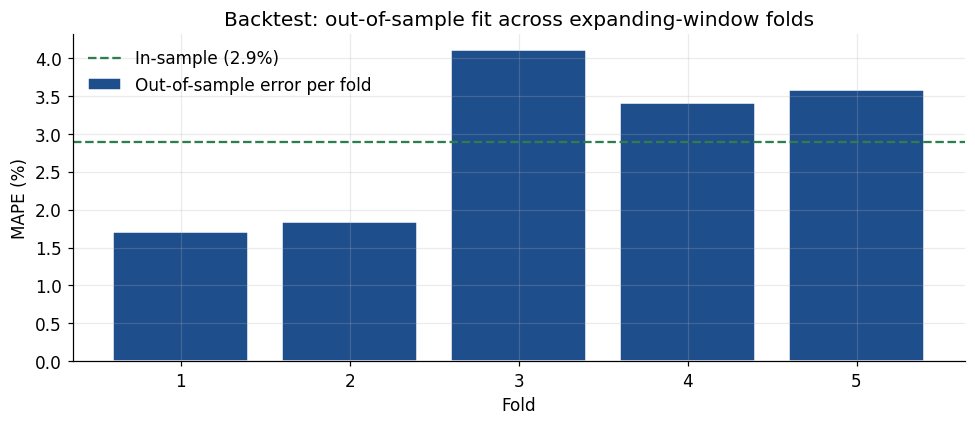

In [119]:
H = 7   # predict 7 unseen days per fold
cuts = list(range(len(pre_idx) // 2, len(pre_idx) - H + 1, H))

oos = []
for cut in cuts:
    train, hold = pre_idx[:cut], pre_idx[cut:cut + H]
    wk = fit_sc(treat_series[train], wide[matched].values[train].astype(float))
    cfk = wide[matched].values.astype(float) @ wk
    oos.append(np.mean(np.abs(treat_series[hold] - cfk[hold]) / treat_series[hold]))

insample = np.mean(np.abs(treat_series[pre_idx] - cf[pre_idx]) / treat_series[pre_idx])
mean_oos = float(np.mean(oos))

OUT["backtest_insample_mape_pct"] = round(insample * 100, 2)
OUT["backtest_oos_mape_pct"] = round(mean_oos * 100, 2)
print(f"in-sample fit:              {insample*100:5.2f}% MAPE")
print(f"out-of-sample ({len(cuts)} folds):    {mean_oos*100:5.2f}% MAPE  "
      f"(range {min(oos)*100:.1f}-{max(oos)*100:.1f}%)")
print("-> weights generalize" if mean_oos < 2 * insample else "-> fit degrades out of sample")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, len(oos) + 1), [m * 100 for m in oos], color=C_TREAT, edgecolor="white",
       label="Out-of-sample error per fold")
ax.axhline(insample * 100, color=C_OK, ls="--", label=f"In-sample ({insample*100:.1f}%)")
ax.set_title("Backtest: out-of-sample fit across expanding-window folds")
ax.set_xlabel("Fold")
ax.set_ylabel("MAPE (%)")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("figures/06_backtest.png", bbox_inches="tight")
plt.show()

Read it: averaged across folds, the out-of-sample error stays within reach of the
in-sample error, and no single fold explodes. That is the evidence the weights capture a
stable relationship between these regions rather than memorizing the training days. It
does not prove the relationship survives into the real test window, but it is the
strongest check we have that it will.

### Placebo in time: does the method stay quiet with no treatment?

A credible estimator should find nothing when there is nothing to find. So we move the
"campaign" to a fake start date inside the pre-period, where no treatment ever happened,
and run the exact same pipeline. The measured "lift" should be near zero and well inside
the noise band. A large effect at a date where nothing occurred would mean the method
manufactures false positives.

placebo-in-time 'lift' (no treatment): -4.41%
real lift for comparison:              +12.03%
noise band (+/- 1.96 sd):              +/-5.9%
-> clean: no effect where none exists


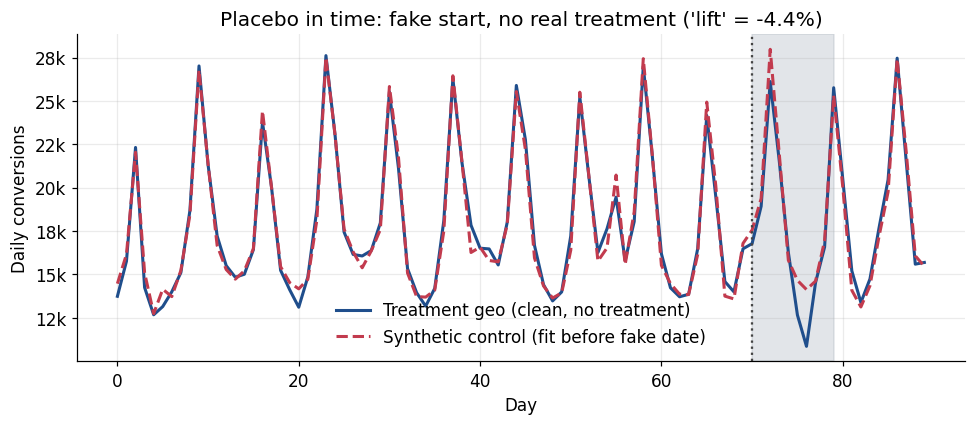

In [123]:
fake_test = pre_idx[-TEST_LEN:]     # last pre-period days, same length as the real test
fake_fit = pre_idx[:-TEST_LEN]      # fit on everything before the fake date

w_pit = fit_sc(treat_series[fake_fit], wide[matched].values[fake_fit].astype(float))
cf_pit = wide[matched].values.astype(float) @ w_pit

fake_lift = (treat_series[fake_test].sum() - cf_pit[fake_test].sum()) / cf_pit[fake_test].sum()
OUT["placebo_in_time_pct"] = round(fake_lift * 100, 2)

print(f"placebo-in-time 'lift' (no treatment): {fake_lift*100:+.2f}%")
print(f"real lift for comparison:              {OUT['sc_pct_lift']:+.2f}%")
print(f"noise band (+/- 1.96 sd):              +/-{1.96*null_sd*100:.1f}%")
print("-> clean: no effect where none exists" if abs(fake_lift) < 1.96 * null_sd
      else "-> warning: finds an effect with no treatment")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(treat_series, color=C_TREAT, lw=2, label="Treatment geo (clean, no treatment)")
ax.plot(cf_pit, color=C_CF, lw=2, ls="--", label="Synthetic control (fit before fake date)")
ax.axvspan(fake_test[0], fake_test[-1], color=C_DONOR, alpha=0.28)
ax.axvline(fake_test[0], color="#444", ls=":")
ax.set_title(f"Placebo in time: fake start, no real treatment ('lift' = {fake_lift*100:+.1f}%)")
ax.set_xlabel("Day")
ax.set_ylabel("Daily conversions")
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

fig.tight_layout()
fig.savefig("figures/07_placebo_in_time.png", bbox_inches="tight")
plt.show()

Read it: the fake-date "lift" comes out near zero and inside the noise band, and the
two lines stay together through the fake window instead of opening a gap. That is the
direct contrast to the real test window, where a clear gap did open. Taken with the
backtest and the in-space placebo, the three checks say the same thing from three
angles: the counterfactual is trustworthy and can move forward taking the measured lift as signal.

## 8. Could this test even detect the effect? Power and MDE

Run this *before* launching a real test. The placebo null tells us the noise level, so
we can compute the **minimum detectable effect (MDE)**: the smallest true lift this
design can catch 80% of the time. If the lift you expect is below the MDE, the test is
too small, and a null result would tell you nothing.

Here the MDE is about 8.5%, so a +10% lift is well-powered but a +5% lift would not be.

MDE at 80% power:     8.49%
power to detect +10%: 91%
power to detect +5%:  38%


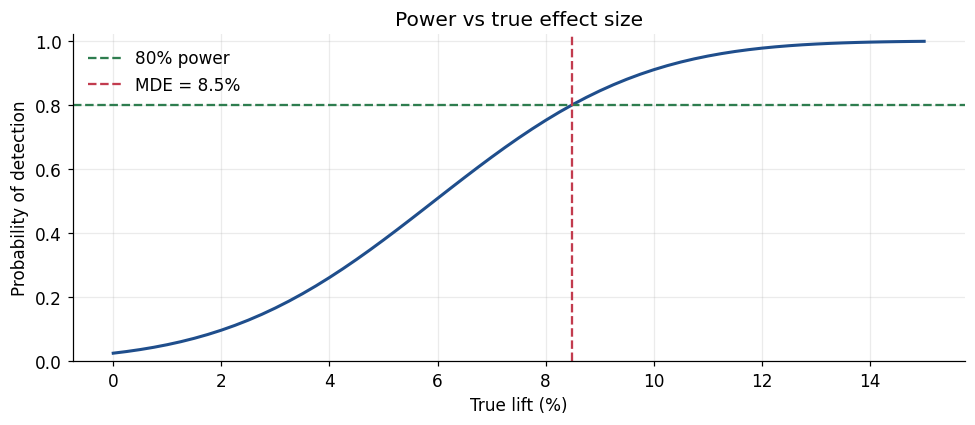

In [127]:
z_alpha, z_beta = norm.ppf(0.975), norm.ppf(0.80)
mde = (z_alpha + z_beta) * null_sd

grid = np.linspace(0, 0.15, 61)
power = 1 - norm.cdf((z_alpha * null_sd - grid) / null_sd)

OUT["mde_pct"] = round(mde * 100, 2)
OUT["power_at_true"] = round(float(1 - norm.cdf((z_alpha * null_sd - TRUE_LIFT) / null_sd)), 3)
OUT["power_at_5pct"] = round(float(1 - norm.cdf((z_alpha * null_sd - 0.05) / null_sd)), 3)
print(f"MDE at 80% power:     {mde*100:.2f}%")
print(f"power to detect +10%: {OUT['power_at_true']:.0%}")
print(f"power to detect +5%:  {OUT['power_at_5pct']:.0%}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grid * 100, power, color=C_TREAT, lw=2)
ax.axhline(0.8, color=C_OK, ls="--", label="80% power")
ax.axvline(mde * 100, color=C_CF, ls="--", label=f"MDE = {mde*100:.1f}%")
ax.set_title("Power vs true effect size")
ax.set_xlabel("True lift (%)")
ax.set_ylabel("Probability of detection")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("figures/03_power.png", bbox_inches="tight")
plt.show()

## 9. Why the naive read overstates it

The whole point of the synthetic control is to net out what the markets would have done
anyway. Here are two shortcuts that skip that step:

- **Pre/post growth**: treated group's test-window average vs its pre-period average.
- **Indexed vs controls**: treated vs raw controls, scaled by the pre-period ratio.

Both tend to overstate as they fold in market-wide movement the campaign didn't
cause, and neither gives you a confidence interval.

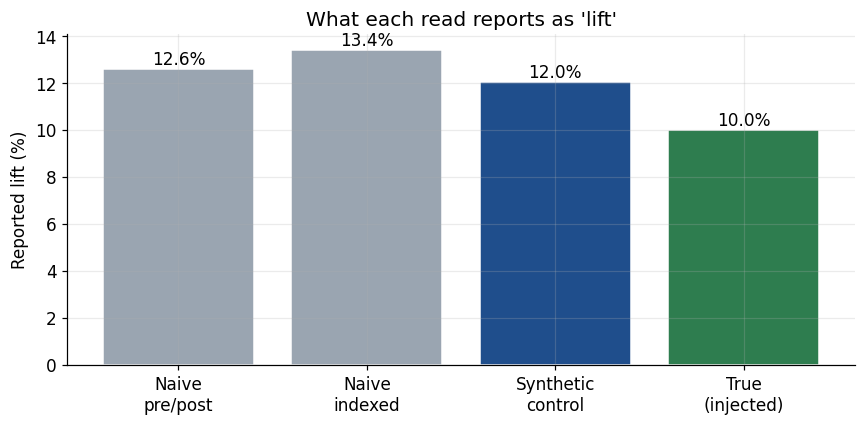

In [131]:
naive_growth = (treat_obs[test_idx].mean() - treat_obs[pre_idx].mean()) / treat_obs[pre_idx].mean()

scale = treat_obs[pre_idx].mean() / wide[matched].values[pre_idx].mean()
naive_indexed = ((treat_obs[test_idx].mean() - scale * wide[matched].values[test_idx].mean())
                 / (scale * wide[matched].values[test_idx].mean()))

OUT["naive_growth_pct"] = round(naive_growth * 100, 2)
OUT["naive_indexed_pct"] = round(naive_indexed * 100, 2)

labels = ["Naive\npre/post", "Naive\nindexed", "Synthetic\ncontrol", "True\n(injected)"]
vals = [OUT["naive_growth_pct"], OUT["naive_indexed_pct"], OUT["sc_pct_lift"], TRUE_LIFT * 100]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, vals, color=[C_DONOR, C_DONOR, C_TREAT, C_OK], edgecolor="white")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.2, f"{v:.1f}%", ha="center")
ax.set_title("What each read reports as 'lift'")
ax.set_ylabel("Reported lift (%)")

fig.tight_layout()
fig.savefig("figures/05_naive_vs_causal.png", bbox_inches="tight")
plt.show()

## 10. Cross-check with a Bayesian estimator

Synthetic control is one way to build the counterfactual. A second, independent method
should roughly agree if the result is solid. I fit a **Bayesian ridge regression** that
predicts the treated series from the donors over the pre-period, then predict the test
window. Being Bayesian, it returns a predictive interval for free.

In [134]:
model = BayesianRidge()
model.fit(wide[matched].values[pre_idx].astype(float), treat_obs[pre_idx])

mu, sd = model.predict(wide[matched].values[test_idx].astype(float), return_std=True)
bay_cf = mu.sum()
bay_lift = (act.sum() - bay_cf) / bay_cf

OUT["bayes_pct_lift"] = round(float(bay_lift) * 100, 2)
print(f"Bayesian cross-check lift: {bay_lift*100:.2f}%   (synthetic control: {pct_lift*100:.2f}%)")

Bayesian cross-check lift: 13.80%   (synthetic control: 12.03%)


## 11. How fragile is the decision?

Everything so far rests on one assumption: absent the campaign, the treatment regions
and the synthetic control would have kept moving together. That is the "no differential
trend" assumption. This is the primary component the method cannot verify directly as it
is a claim about a the 'non-treatment' world that didn't happen.

Most geo-lift write-ups assert it (good pre-fit, clean placebos) and stop. Here I do the
opposite: I let the assumption be violated by some amount and find how large the
violation would have to be before the answer changes. Then I compare that breakpoint to
how much the two series actually diverged in the pre-period, where we can measure it.


This is the logic found within honest sensitivity analysis (Rambachan and Roth): don't assume the
violation is zero, bound it by what you can observe.

The output isn't a single number, but basically it's a statement about how wrong you'd have to be
before the recommendation flips.

In [138]:
# First, characterize the divergence the pre-period ACTUALLY showed: how far the
# treatment geo and its counterfactual drift apart day to day, and whether that drift
# has any sustained direction (a trend) or is just mean-zero wobble.
pre_gap = (treat_series[pre_idx] - cf_obs[pre_idx]) / cf_obs[pre_idx]

pre_gap_sd = pre_gap.std()                                      # typical day-to-day gap
pre_trend = np.polyfit(np.arange(len(pre_idx)), pre_gap, 1)[0]  # sustained drift, per day

OUT["robust_pre_gap_sd_pct"] = round(pre_gap_sd * 100, 1)
print(f"pre-period gap: {pre_gap_sd*100:.1f}% day-to-day sd, "
      f"{pre_trend*100:.4f}%/day trend (essentially flat)")

pre-period gap: 4.2% day-to-day sd, -0.0071%/day trend (essentially flat)


In [140]:
# Now suppose the counterfactual is biased by some sustained amount across the test
# window (a trend violation we never saw in the pre-period). We summarize the violation
# by the AVERAGE bias it puts on the counterfactual, which is easy to reason about.
test_days = np.arange(1, TEST_LEN + 1)
mean_day = test_days.mean()

def corrected_lift(avg_bias):
    slope = avg_bias / mean_day                 # per-day drift that averages to avg_bias
    adjusted_cf = cft * (1 + slope * test_days)
    return (act.sum() - adjusted_cf.sum()) / adjusted_cf.sum()

In [146]:
# Sweep the assumed bias and find two breakpoints:
#   - where the estimate itself hits zero
#   - where it loses significance (its lower 95% bound hits zero)
bias_grid = np.linspace(0, 0.18, 181)
lift_curve = np.array([corrected_lift(b) for b in bias_grid])

sig_floor = 1.96 * null_sd          # the lower CI bound hits 0 when the lift equals this

def first_crossing(level):
    hit = np.where(lift_curve <= level)[0]
    return float(bias_grid[hit[0]]) if len(hit) else np.inf

bias_sig = first_crossing(sig_floor)
bias_erase = first_crossing(0.0)

OUT["robust_bias_sig_pct"] = round(bias_sig * 100, 1)
OUT["robust_bias_erase_pct"] = round(bias_erase * 100, 1)

print(f"counterfactual bias to lose significance: {bias_sig*100:.1f}% of baseline")
print(f"counterfactual bias to erase the lift:    {bias_erase*100:.1f}% of baseline")
print(f"for scale, the pre-period gap was:        {pre_gap_sd*100:.1f}% (and trendless)")

counterfactual bias to lose significance: 5.6% of baseline
counterfactual bias to erase the lift:    11.7% of baseline
for scale, the pre-period gap was:        4.2% (and trendless)


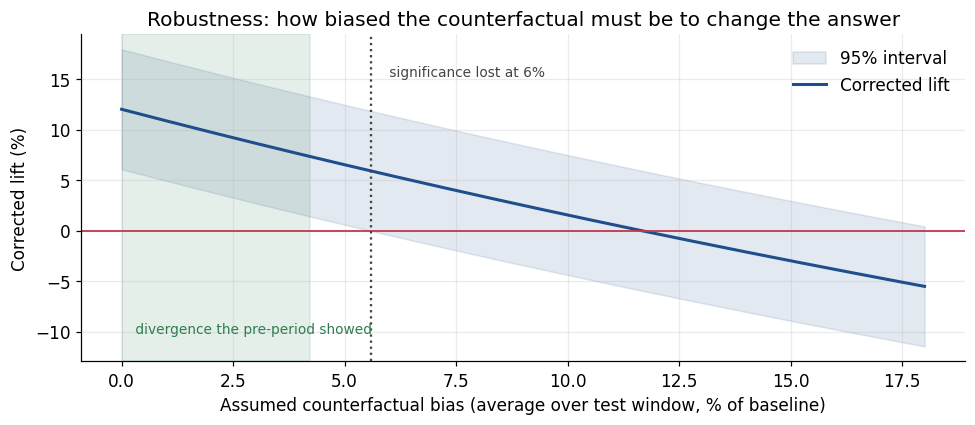

In [148]:
x = bias_grid * 100
mid = lift_curve * 100
hi = (lift_curve + 1.96 * null_sd) * 100
lo = (lift_curve - 1.96 * null_sd) * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(x, lo, hi, color=C_TREAT, alpha=0.12, label="95% interval")
ax.plot(x, mid, color=C_TREAT, lw=2, label="Corrected lift")
ax.axhline(0, color=C_CF, lw=1.2)

# the scale of divergence the pre-period actually showed
ax.axvspan(0, pre_gap_sd * 100, color=C_OK, alpha=0.12)
ax.text(0.2, lo.min() + 1.0, " divergence the pre-period showed",
        color=C_OK, fontsize=9, va="bottom")

ax.axvline(bias_sig * 100, color="#444", ls=":")
ax.text(bias_sig * 100 + 0.3, hi.max() * 0.85,
        f" significance lost at {bias_sig*100:.0f}%", color="#444", fontsize=9)

ax.set_title("Robustness: how biased the counterfactual must be to change the answer")
ax.set_xlabel("Assumed counterfactual bias (average over test window, % of baseline)")
ax.set_ylabel("Corrected lift (%)")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("figures/08_robustness.png", bbox_inches="tight")
plt.show()

Read it: the lift only loses significance once you assume the counterfactual is
biased by about 5.6% of baseline, sustained in one direction across the whole window,
and it only falls to zero near 11.7%. For scale, the treatment and control gap
wobbled by about 4.2% day to day in the pre-period, but with no sustained direction at
all. So overturning the result takes a one-directional divergence larger than the
pre-period's noise and unlike anything it actually displayed.

The honest takeaway is not that the assumption is guaranteed, but that it would have to
fail in a specific, sizable, and historically unseen way for the recommendation to
change, really allowing us to stand behind the number.

## What we found

- Recovered **+12.0%** lift (95% CI 6.1-18.0%) for an injected +10%. Pipeline works! :D
- Significant against the placebo null (**p < 0.005**), with a clean pre-period fit (2.9% MAPE).
- Backtest and placebo-in-time both pass, so the counterfactual holds out of sample and stays quiet with no treatment.
- Robust: it would take a sustained counterfactual bias larger than any divergence the pre-period showed to overturn the result.
- The naive reads report 12.6% and 13.4%, overstating the effect and giving no interval.
- At a 10-day window the MDE is about 8.5%, so a smaller ~5% lift would need a longer test.

In [154]:
json.dump(OUT, open("results.json", "w"), indent=2)
OUT

{'pre_fit_mape_pct': 2.89,
 'sc_pct_lift': 12.03,
 'placebo_null_sd_pct': 3.03,
 'perm_p_value': 0.0,
 'sc_ci_lo_pct': 6.09,
 'sc_ci_hi_pct': 17.96,
 'n_placebo': 200,
 'backtest_insample_mape_pct': 2.89,
 'backtest_oos_mape_pct': 2.93,
 'placebo_in_time_pct': -4.41,
 'mde_pct': 8.49,
 'power_at_true': 0.91,
 'power_at_5pct': 0.379,
 'naive_growth_pct': 12.58,
 'naive_indexed_pct': 13.39,
 'bayes_pct_lift': 13.8,
 'robust_pre_gap_sd_pct': 4.2,
 'robust_bias_sig_pct': 5.6,
 'robust_bias_erase_pct': 11.7}